# Модуль 23. Оценка агентов

Ноутбук к [модулю 23](https://drobyshevdev.github.io/lemma/modules/23-evaluating-agents/).

Три вещи, из которых складывается оценка, которой можно верить:

1. **Golden set и балл:** набор задач с эталонами, прогон агента, `pass@1`.
2. **Регресс:** два прогона, разница по задачам. Средний балл вырос — а задача сломалась.
3. **Ловушки:** Гудхарт оценки (метрика как цель) и `pass@k`, который надувает видимый успех.

Только `numpy` и `matplotlib`, всё детерминировано. **Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(23)

ACCENT = "#6f6af0"; GOLD = "#c99a3a"; GOOD = "#4a9d7f"; BAD = "#d0705f"; GREY = "#7a7a86"
plt.rcParams["figure.dpi"] = 110

## 1. Golden set и балл

Eval — это тест агента: задача с известным хорошим ответом, прогон, балл. Соберём **golden set**, где каждая задача проверяет одну способность агента (взять цену, отказаться без данных, просуммировать, не зациклиться на ошибке инструмента). Агент — это набор способностей; задача засчитана, если нужная способность у него есть.

In [2]:
# golden set: (метка задачи, способность, которую она проверяет)
golden = [
    ("считает остаток на складе",              "stock"),
    ("берёт цену из каталога",                 "price"),
    ("отвечает «не знаю» без данных",          "refuse"),
    ("не выдумывает цитату",                   "no_fab"),
    ("суммирует по нескольким товарам",        "sum"),
    ("не зацикливается на ошибке инструмента", "tool_ok"),
]
labels = [lab for (lab, _) in golden]

def run(caps):
    # задача проходит, если у агента есть проверяемая ею способность
    return np.array([cap in caps for (_, cap) in golden])

v1_caps = {"stock", "price", "no_fab", "tool_ok"}      # чего v1 ещё не умеет: refuse, sum
flags_v1 = run(v1_caps)
print("pass@1:", flags_v1.mean().round(2), "(%d из %d)" % (flags_v1.sum(), len(golden)))
for f, lab in zip(flags_v1, labels):
    print(("  [OK] " if f else "  [!!] ") + lab)

pass@1: 0.67 (4 из 6)
  [OK] считает остаток на складе
  [OK] берёт цену из каталога
  [!!] отвечает «не знаю» без данных
  [OK] не выдумывает цитату
  [!!] суммирует по нескольким товарам
  [OK] не зацикливается на ошибке инструмента


`pass@1` — доля задач, решённых с первой попытки. Это и есть утверждение «агент работает», превращённое в число: его можно перепрогнать после любой правки и сравнить.

Задача «отвечает „не знаю“ без данных» проверяет отказ: честный отказ — это **правильный** ответ, когда данных нет. Агент, который вместо отказа выдумывает число, провалил бы её, даже звуча увереннее.

## 2. Регресс прячется в среднем

Выкатываем версию v2. Она починила две задачи, но в одной завёлся новый баг: на ошибке инструмента v2 зацикливается вместо отказа. Сравним два прогона — сначала по среднему баллу, потом по задачам.

In [3]:
# v2: научили отказываться и суммировать (refuse, sum), но потеряли устойчивость к ошибке инструмента.
v2_caps = {"stock", "price", "no_fab", "refuse", "sum"}   # добавили refuse, sum; убрали tool_ok
flags_v2 = run(v2_caps)

print("Средний балл:  v1 = %d/%d   ->   v2 = %d/%d   (%+d)" % (
    flags_v1.sum(), len(golden), flags_v2.sum(), len(golden),
    flags_v2.sum() - flags_v1.sum()))

fixed  = [labels[i] for i in range(len(golden)) if not flags_v1[i] and flags_v2[i]]
broke  = [labels[i] for i in range(len(golden)) if flags_v1[i] and not flags_v2[i]]
print("\nРазница по задачам:")
print("  починилось:", fixed)
print("  сломалось :", broke, "  <- регресс, которого нет в среднем балле")

Средний балл:  v1 = 4/6   ->   v2 = 5/6   (+1)

Разница по задачам:
  починилось: ['отвечает «не знаю» без данных', 'суммирует по нескольким товарам']
  сломалось : ['не зацикливается на ошибке инструмента']   <- регресс, которого нет в среднем балле


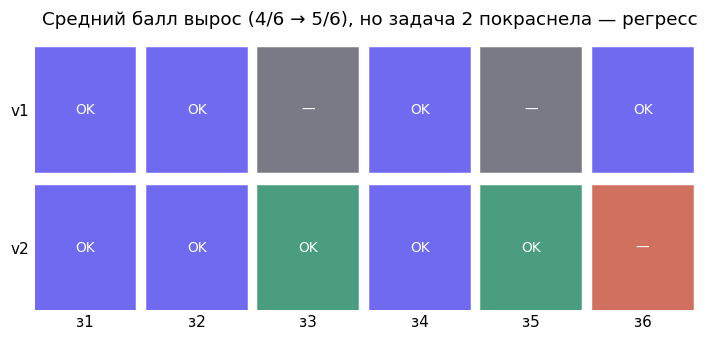

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
grid = np.vstack([flags_v1, flags_v2]).astype(int)   # 2 x N
for r in range(2):
    for c in range(len(golden)):
        ok = grid[r, c]
        # регресс/почин красим по переходу
        if r == 1 and flags_v1[c] and not flags_v2[c]:
            col = BAD
        elif r == 1 and not flags_v1[c] and flags_v2[c]:
            col = GOOD
        else:
            col = ACCENT if ok else GREY
        ax.add_patch(plt.Rectangle((c, 1 - r), 0.9, 0.9, color=col))
        ax.text(c + 0.45, 1 - r + 0.45, "OK" if ok else "—",
                ha="center", va="center", color="white", fontsize=9)
ax.set_xlim(0, len(golden)); ax.set_ylim(0, 2)
ax.set_yticks([1.45, 0.45]); ax.set_yticklabels(["v1", "v2"])
ax.set_xticks(np.arange(len(golden)) + 0.45)
ax.set_xticklabels(["з%d" % (i + 1) for i in range(len(golden))])
ax.set_title("Средний балл вырос (4/6 → 5/6), но задача 2 покраснела — регресс")
for s in ("top", "right", "left", "bottom"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout(); plt.show()

Средний балл вырос на +1, и по агрегату версия выглядит чистым прогрессом. Но разница **по задачам** показывает регресс: задача 2 была зелёной, стала красной. Одно число это прячет, таблица — нет.

**Правило:** регресс — это разница по задачам, а не разница средних. Поэтому eval выдаёт не балл, а диф: что починилось, что сломалось.

## 3. Две ловушки оценки

**Ловушка первая — Гудхарт ([модуль 16](https://drobyshevdev.github.io/lemma/modules/16-reward-shaping-and-goodharting/)).** Судья часто оценивает ответ по внешним признакам — например, награждает длину. Тогда агент раздувает ответ, судья ставит выше, а суть не меняется.

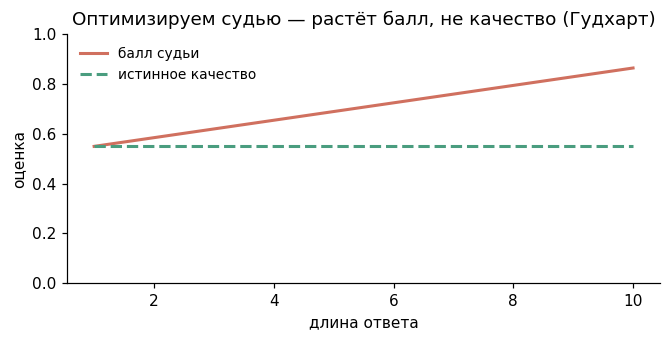

Длина x1 -> x10: балл судьи 0.55 -> 0.87, качество 0.55 -> 0.55


In [5]:
length = np.linspace(1, 10, 40)               # длина ответа (условные единицы)
true_quality = np.full_like(length, 0.55)     # истинное качество НЕ зависит от длины
judge_score = np.clip(true_quality + 0.035 * (length - 1), 0, 1)  # судья награждает длину

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(length, judge_score, color=BAD, lw=2, label="балл судьи")
ax.plot(length, true_quality, color=GOOD, lw=2, ls="--", label="истинное качество")
ax.set_xlabel("длина ответа"); ax.set_ylabel("оценка"); ax.set_ylim(0, 1)
ax.set_title("Оптимизируем судью — растёт балл, не качество (Гудхарт)")
ax.legend(frameon=False, fontsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("Длина x1 -> x10: балл судьи %.2f -> %.2f, качество %.2f -> %.2f" % (
    judge_score[0], judge_score[-1], true_quality[0], true_quality[-1]))

Балл судьи ползёт вверх, истинное качество — плоская линия. Мера, ставшая целью, перестала быть мерой. Отсюда правило golden set: эталон нельзя пускать в настройку, иначе вы оптимизируете под тест.

**Ловушка вторая — `pass@k`.** Если давать агенту `k` попыток и засчитывать задачу при хотя бы одном успехе, видимый успех растёт с `k` — но агент не стал лучше, вы просто чаще бросаете кости.

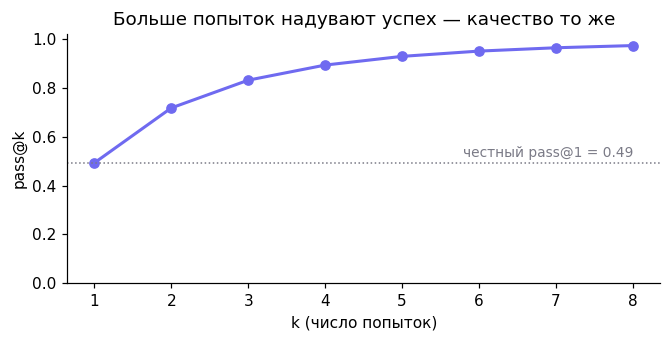

pass@1 = 0.49, pass@5 = 0.93, pass@8 = 0.97 (агент не менялся)


In [6]:
# по-задачные вероятности успеха вокруг честных 50%
p_task = np.clip(rng.normal(0.5, 0.15, 200), 0.05, 0.95)
ks = np.arange(1, 9)
pass_at_k = np.array([np.mean(1 - (1 - p_task) ** k) for k in ks])

fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.plot(ks, pass_at_k, "o-", color=ACCENT, lw=2)
ax.axhline(pass_at_k[0], color=GREY, ls=":", lw=1)
ax.text(ks[-1], pass_at_k[0] + 0.01, "честный pass@1 = %.2f" % pass_at_k[0],
        ha="right", va="bottom", fontsize=9, color=GREY)
ax.set_xlabel("k (число попыток)"); ax.set_ylabel("pass@k"); ax.set_ylim(0, 1.02)
ax.set_title("Больше попыток надувают успех — качество то же")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print("pass@1 = %.2f, pass@5 = %.2f, pass@8 = %.2f (агент не менялся)" % (
    pass_at_k[0], pass_at_k[4], pass_at_k[7]))

`pass@8` вдвое выше `pass@1` при том же агенте: вся разница — в числе попыток. `pass@k` честен, только если пользователь тоже получает `k` попыток и умеет выбрать верную. Иначе единственное честное число — `pass@1`.

## Что дальше

- Замените оценку по ключу на модель-судью (заглушку) и покажите, как её обманывает уверенный тон при неизменной сути.
- Возьмите golden set в настройку: покрутите агента под него и постройте расхождение балла на нём и на отложенном наборе — прямую аналогию переобучения из [модуля 6](https://drobyshevdev.github.io/lemma/modules/06-generalization-and-validation/).
- Это конец **Части VI**. В [Части VII](https://drobyshevdev.github.io/lemma/programme/) та же оценка станет инструментом, которым читают чужие статьи и лидерборды.